## Import Libraries

In [37]:
# ==============================================================
# Neural diffusion stepper – variable Δt, no physics input
# ==============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# ---- High-quality plotting setup for A0 poster printing ----
# PDF format preserves vector quality and scales perfectly for printing
import os
os.makedirs('diffusion figures', exist_ok=True)  # Create directory for figures

plt.rcParams['figure.dpi'] = 300  # DPI for display
plt.rcParams['savefig.format'] = 'pdf'  # PDF format for vector graphics (perfect quality)
plt.rcParams['savefig.pad_inches'] = 0.1
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['grid.linewidth'] = 0.8
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['lines.markersize'] = 6
plt.rcParams['lines.antialiased'] = True
plt.rcParams['patch.antialiased'] = True
plt.rcParams['text.antialiased'] = True
plt.rcParams['figure.max_open_warning'] = 0

# ---- Device setup (CPU / GPU) ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
CUDA version: 12.1
GPU: NVIDIA GeForce RTX 4090


## Diffusion Solver + Data Prep
Defines the solver, generates data, and prepares train/test splits.


Generating 1D diffusion data...
Data shape: (50001, 256)


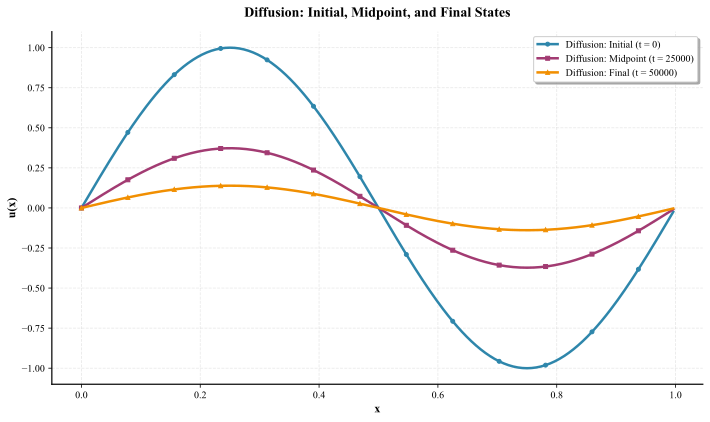

In [38]:
# ============================================================
# 1. 1D Diffusion Solver (Generate Data)
# ============================================================
def diffusion_solver(u0, nu=0.01, dx=1/128, dt=1e-4, n_steps=50000):
    u = u0.copy()

    traj = [u.copy()]
    for _ in range(n_steps):
        u_new = u.copy()

        # Periodic BC: update all points including boundaries
        # Use periodic neighbors: u[-1] neighbors with u[0], u[0] neighbors with u[-1]
        u_left = np.roll(u, 1)   # shift right: u[i-1] with periodic wrap
        u_right = np.roll(u, -1) # shift left: u[i+1] with periodic wrap
        
        # Laplacian for all points (periodic)
        lap = (u_right - 2*u + u_left) / dx**2
        u_new = u + nu * dt * lap

        u = u_new
        traj.append(u.copy())

    return np.stack(traj)


# Generate 1D data
Nx = 256
dx = 1/Nx
dt0 = 1e-4
nu = 0.01
n_steps = 50000

x = np.linspace(0, 1, Nx, endpoint=False)
u0 = np.sin(2*np.pi*x)

print("Generating 1D diffusion data...")
data = diffusion_solver(u0, nu, dx, dt0, n_steps)
print(f"Data shape: {data.shape}")

fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

ax.plot(x, data[0], linewidth=2.5, label="Diffusion: Initial (t = 0)", color='#2E86AB', marker='o', markersize=4, markevery=20)
ax.plot(x, data[n_steps//2], linewidth=2.5, label=f"Diffusion: Midpoint (t = {n_steps//2})", color='#A23B72', marker='s', markersize=4, markevery=20)
ax.plot(x, data[-1], linewidth=2.5, label=f"Diffusion: Final (t = {n_steps})", color='#F18F01', marker='^', markersize=4, markevery=20)

ax.set_title("Diffusion: Initial, Midpoint, and Final States", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("x", fontsize=12, fontweight='bold')
ax.set_ylabel("u(x)", fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
ax.legend(frameon=True, fancybox=True, shadow=True, loc='best')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
# Save as PDF in diffusion figures folder (vector graphics preserve quality)
fig.savefig('diffusion figures/diffusion_initial_midpoint_final.pdf', bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()

# Train/test split
T_train = 25000
u_train = torch.tensor(data[:T_train], dtype=torch.float32, device=device)
u_test_true = torch.tensor(data[T_train:], dtype=torch.float32, device=device)


## Define MLP Stepper Model
Neural time-stepper with 3 hidden layers (128 units each) and Adam optimizer.


In [7]:
# -----------------------
# 3. Model 
# -----------------------
class MLPStepper(nn.Module):
    def __init__(self, in_dim=4, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1)
        )
    def forward(self, u_left, u_center, u_right, dt_norm):
        inp = torch.stack([u_left, u_center, u_right, dt_norm], dim=-1)
        du = self.net(inp).squeeze(-1)
        return u_center + 0.005*du

model = MLPStepper().to(device)
opt = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

## Training Loop
Trains the model for variable Δt using multi-step batches.


In [8]:
epochs = 200
batch_size = 512
max_mult = 8
u = u_train

# Track MSE per epoch
epoch_losses = []

for epoch in range(epochs):
    losses = []

    for mult in range(1, max_mult+1):   # <--- iterate dt=1..8

        num_batches = (u.shape[0] - mult - 1) // batch_size

        for _ in range(num_batches):

            # random times but fixed dt per pass
            t = torch.randint(0, u.shape[0] - mult - 1,
                              (batch_size,), device=device)

            # dt = mult for whole batch
            dt_mult = torch.full((batch_size, 1),
                                 float(mult), device=device)

            # expand dt to match spatial dim
            dt_norm = dt_mult.repeat(1, u.shape[1])

            u_t = u[t]
            u_next = u[t + mult]

            u_left  = torch.roll(u_t, +1, dims=1)
            u_right = torch.roll(u_t, -1, dims=1)

            u_pred = model(u_left, u_t, u_right, dt_norm)
            # Periodic BC: no enforcement needed (torch.roll already handles periodic boundaries)

            delta_true = u_next - u_t
            delta_pred = u_pred - u_t
            loss = ((delta_pred - delta_true)**2).mean()

            opt.zero_grad()
            loss.backward()
            opt.step()

            losses.append(loss.item())

    epoch_mean_loss = np.mean(losses)
    epoch_losses.append(epoch_mean_loss)
    print(f"Epoch {epoch+1}/{epochs} - MSE: {epoch_mean_loss:.6e}")


Epoch 1/200 - MSE: 4.199282e-09
Epoch 2/200 - MSE: 5.437598e-10
Epoch 3/200 - MSE: 1.461542e-10
Epoch 4/200 - MSE: 6.391683e-11
Epoch 5/200 - MSE: 4.627196e-11
Epoch 6/200 - MSE: 3.784265e-11
Epoch 7/200 - MSE: 3.099586e-11
Epoch 8/200 - MSE: 2.916103e-11
Epoch 9/200 - MSE: 2.701730e-11
Epoch 10/200 - MSE: 2.483269e-11
Epoch 11/200 - MSE: 2.341752e-11
Epoch 12/200 - MSE: 2.131558e-11
Epoch 13/200 - MSE: 1.955977e-11
Epoch 14/200 - MSE: 1.857238e-11
Epoch 15/200 - MSE: 1.697552e-11
Epoch 16/200 - MSE: 1.638694e-11
Epoch 17/200 - MSE: 1.502897e-11
Epoch 18/200 - MSE: 1.449007e-11
Epoch 19/200 - MSE: 1.352246e-11
Epoch 20/200 - MSE: 1.299624e-11
Epoch 21/200 - MSE: 1.240146e-11
Epoch 22/200 - MSE: 1.193000e-11
Epoch 23/200 - MSE: 1.149750e-11
Epoch 24/200 - MSE: 1.114861e-11
Epoch 25/200 - MSE: 1.070505e-11
Epoch 26/200 - MSE: 1.046064e-11
Epoch 27/200 - MSE: 1.012718e-11
Epoch 28/200 - MSE: 9.767109e-12
Epoch 29/200 - MSE: 9.567655e-12
Epoch 30/200 - MSE: 9.304967e-12
Epoch 31/200 - MSE:

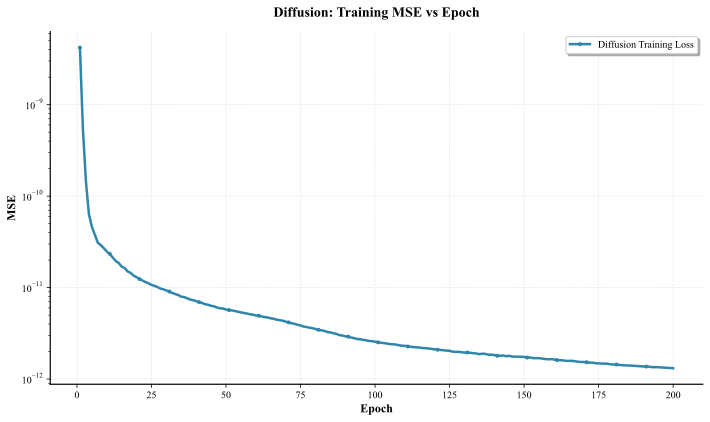

In [39]:
# Plot MSE vs Epoch
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

ax.plot(range(1, len(epoch_losses) + 1), epoch_losses, linewidth=2.5, 
        color='#2E86AB', marker='o', markersize=3, markevery=max(1, len(epoch_losses)//20), 
        label='Diffusion Training Loss')

ax.set_xlabel("Epoch", fontsize=12, fontweight='bold')
ax.set_ylabel("MSE", fontsize=12, fontweight='bold')
ax.set_title("Diffusion: Training MSE vs Epoch", fontsize=14, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
ax.set_yscale('log')  # Use log scale for better visualization
ax.legend(frameon=True, fancybox=True, shadow=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
# Save as PDF in diffusion figures folder (vector graphics preserve quality)
fig.savefig('diffusion figures/diffusion_mse_vs_epoch.pdf', bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()


## Save Model

In [10]:
torch.save(model.state_dict(), "neural_diffusion_stepper2.pt")
print("Model saved!")


Model saved!


## Import Model, I did this so we don't have to train everytime

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = MLPStepper().to(device)

model.load_state_dict(torch.load("neural_diffusion_stepper2.pt", map_location=device))
model.eval()

print("Model loaded successfully!")


Using device: cuda
Model loaded successfully!


C:\Users\amt35\AppData\Local\Temp\ipykernel_7312\1563058203.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("neural_diffusion_stepper2.p

## Rollout on Test Region
Generates predicted trajectory and collects true vs predicted states.


In [12]:
# %%
# =============================================================
# Plot: True vs Predicted (Rollout on Test Region)
# =============================================================

model.eval()

# start from the FIRST test frame (t = 25000)
u_pred = u_test_true[0].clone()     # prediction rollout starts here
u_pred = u_pred.unsqueeze(0)        # [1, Nx]

rollout_pred = [u_pred[0].detach().cpu().numpy()]
rollout_true = [u_test_true[0].detach().cpu().numpy()]

# do rollout for the whole test region
steps = u_test_true.shape[0]

with torch.no_grad():
    for t in range(steps - 1):

        u_now = u_pred[-1] if isinstance(u_pred, list) else u_pred[0]

        # shape = [Nx]
        u_now = u_now.to(device)

        u_left  = torch.roll(u_now, +1)
        u_right = torch.roll(u_now, -1)

        # dt = 1 step during test
        dt_vec = torch.ones_like(u_now)

        u_next = model(u_left, u_now, u_right, dt_vec)
        # Periodic BC: no enforcement needed (torch.roll already handles periodic boundaries)

        rollout_pred.append(u_next.detach().cpu().numpy())
        rollout_true.append(u_test_true[t+1].detach().cpu().numpy())

        u_pred = u_next.unsqueeze(0)

rollout_pred = np.stack(rollout_pred)
rollout_true = np.stack(rollout_true)

print("Rollout shape:", rollout_pred.shape)


Rollout shape: (25001, 256)


## Save Training & Test Tensors for RL 
Exports u_train, u_test, and metadata to .pt files.


In [13]:
import torch
import numpy as np

# Assuming you have 'data' from your diffusion solver
# data shape: [50001, 256] (50000 steps + initial condition)

# -----------------------
# Export Training Data
# -----------------------

# Split the data
T_train = 25000  # first 25k steps for training

# Convert to torch tensor if it's numpy
if isinstance(data, np.ndarray):
    data_tensor = torch.from_numpy(data).float()
else:
    data_tensor = data

# Extract training portion (0 to 25000)
u_train = data_tensor[:T_train + 1]  # +1 to include step 25000

print(f"Training data shape: {u_train.shape}")
print(f"Expected shape: [25001, 256]")

# Save the training data
torch.save(u_train, 'u_train.pt')
print("✓ Saved u_train.pt")

# Optional: Also save test data
u_test = data_tensor[T_train:]
torch.save(u_test, 'u_test.pt')
print(f"✓ Saved u_test.pt (shape: {u_test.shape})")

# Optional: Save other useful information
metadata = {
    'Nx': 256,
    'dx': 1/256,
    'dt0': 1e-4,
    'nu': 0.01,
    'T_train': T_train,
    'n_steps_total': 50000
}
torch.save(metadata, 'metadata.pt')
print("✓ Saved metadata.pt")

print("\n" + "="*60)
print("Files saved:")
print("  - u_train.pt: Training data [25001, 256]")
print("  - u_test.pt: Test data [25001, 256]")
print("  - metadata.pt: Problem parameters")
print("="*60)

Training data shape: torch.Size([25001, 256])
Expected shape: [25001, 256]
✓ Saved u_train.pt
✓ Saved u_test.pt (shape: torch.Size([25001, 256]))
✓ Saved metadata.pt

Files saved:
  - u_train.pt: Training data [25001, 256]
  - u_test.pt: Test data [25001, 256]
  - metadata.pt: Problem parameters


## Multi-Multiplier Comparison (Subplots)
Shows true vs predicted snapshots for several dts


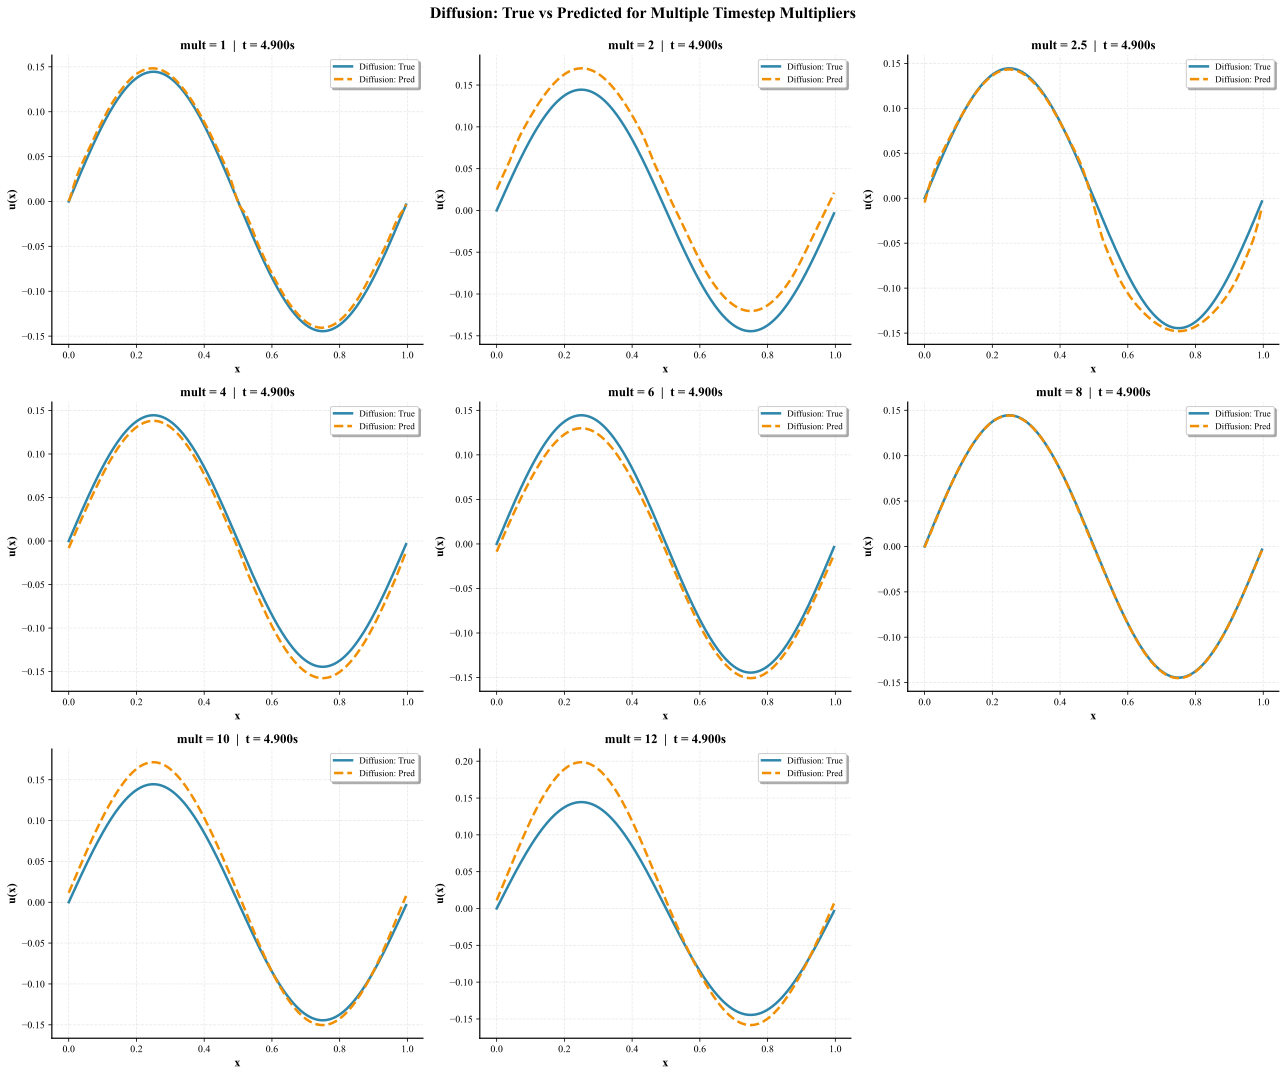

In [42]:
# %%
# =============================================================
# Plot: True vs Predicted for Multiple Timestep Multipliers (Subplots)
# =============================================================

dt0 = 1e-4
train_end_step = T_train   # 25,000
snapshot_index = -1000

idx = snapshot_index % len(rollout_true)
global_step = train_end_step + idx
t_snapshot = global_step * dt0


multipliers = [1,2,2.5,4,6,8,10,12]   # 1,3,5,...,15
n = len(multipliers)

cols = 3
rows = int(np.ceil(n / cols))

fig = plt.figure(figsize=(18, 5 * rows), dpi=300)
fig.suptitle("Diffusion: True vs Predicted for Multiple Timestep Multipliers", 
             fontsize=16, fontweight='bold', y=0.995)

for i, mult in enumerate(multipliers, 1):

    model.eval()

    # --- rollout for this multiplier ---
    u_pred = u_test_true[0].clone().unsqueeze(0)

    rollout_pred_mult = [u_pred[0].detach().cpu().numpy()]
    rollout_true_mult = [u_test_true[0].detach().cpu().numpy()]

    steps = int(u_test_true.shape[0] // mult)  # Convert to int for range()

    with torch.no_grad():
        for t in range(steps - 1):
            u_now = torch.from_numpy(rollout_pred_mult[-1]).to(device)

            u_left  = torch.roll(u_now, +1)
            u_right = torch.roll(u_now, -1)
            dt_vec = torch.ones_like(u_now) * mult

            u_next = model(u_left, u_now, u_right, dt_vec)

            rollout_pred_mult.append(u_next.detach().cpu().numpy())
            # Convert to int for array indexing (handles float multipliers like 2.5)
            true_idx = int((t + 1) * mult)
            rollout_true_mult.append(
                u_test_true[true_idx].detach().cpu().numpy()
            )

    rollout_pred_mult = np.stack(rollout_pred_mult)
    rollout_true_mult = np.stack(rollout_true_mult)

    # index adjusted for this multiplier (convert to int for array indexing)
    idx_mult = int(idx // mult)
    # Ensure index is within bounds
    idx_mult = min(idx_mult, len(rollout_true_mult) - 1)

    # --- subplot ---
    ax = plt.subplot(rows, cols, i)

    ax.plot(x, rollout_true_mult[idx_mult],
            label="Diffusion: True", linewidth=2.5, color='#2E86AB')
    ax.plot(x, rollout_pred_mult[idx_mult],
            label="Diffusion: Pred", linewidth=2.5, linestyle="--", color='#F18F01')

    ax.set_title(f"mult = {mult}  |  t = {t_snapshot:.3f}s", fontweight='bold')
    ax.set_xlabel("x", fontweight='bold')
    ax.set_ylabel("u(x)", fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
    ax.legend(frameon=True, fancybox=True, shadow=True, fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
# Save as PDF in diffusion figures folder (vector graphics preserve quality)
fig.savefig('diffusion figures/diffusion_multiplier_comparison.pdf', bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()

## Multi-Time Snapshots per Multiplier
Plots true vs predicted snapshots at several times for each Δt multiplier.


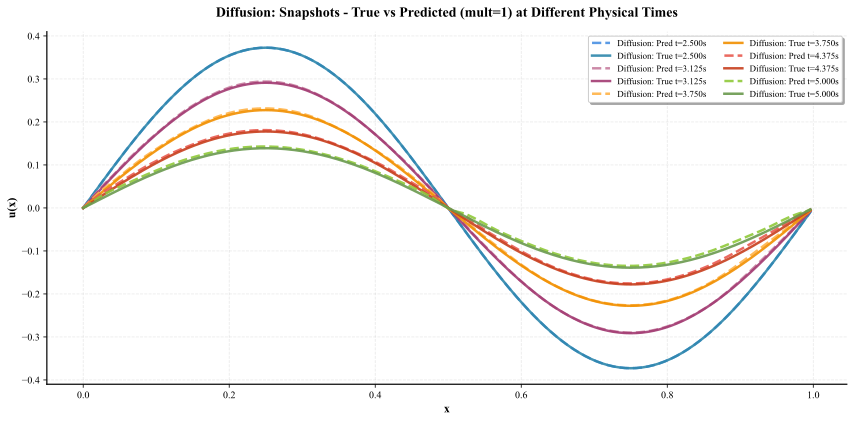

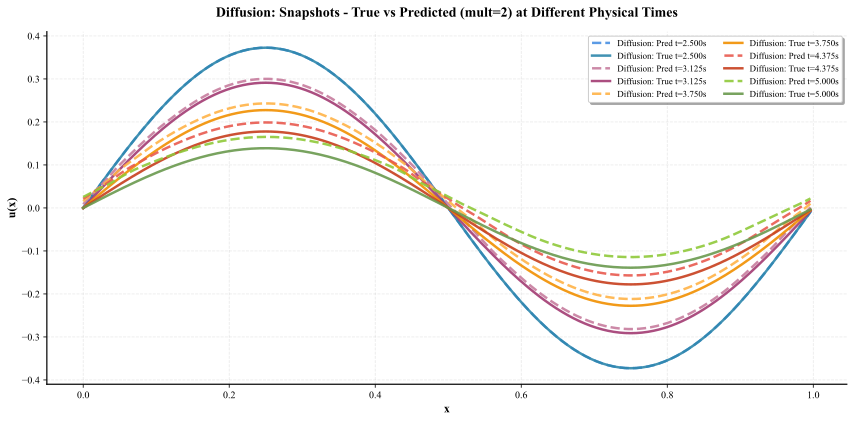

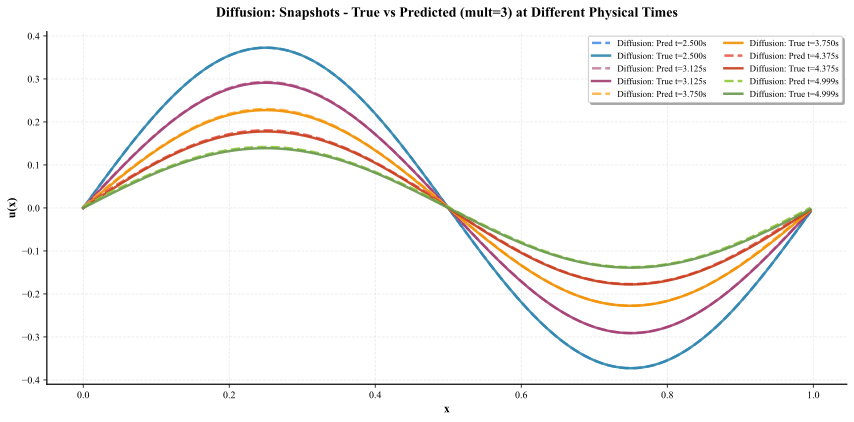

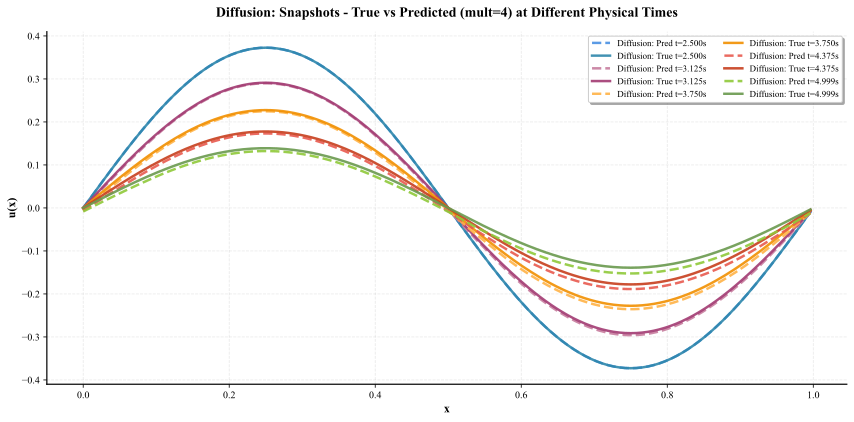

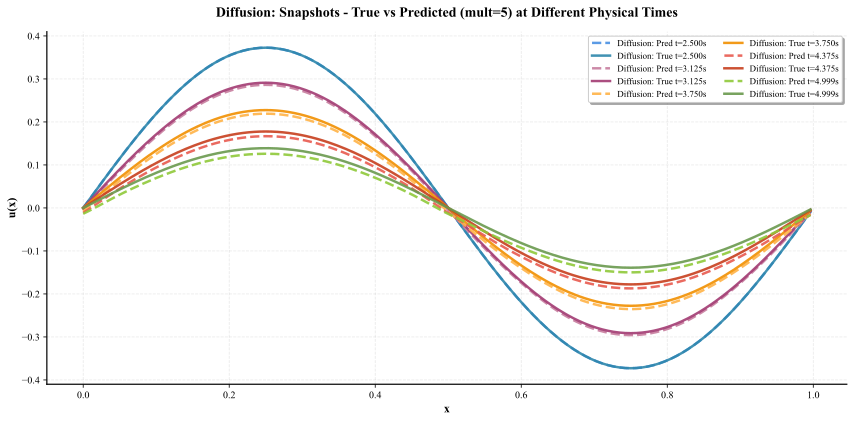

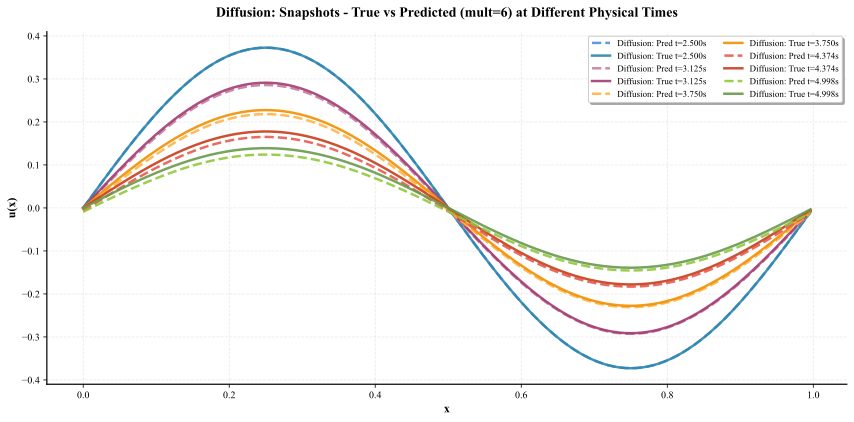

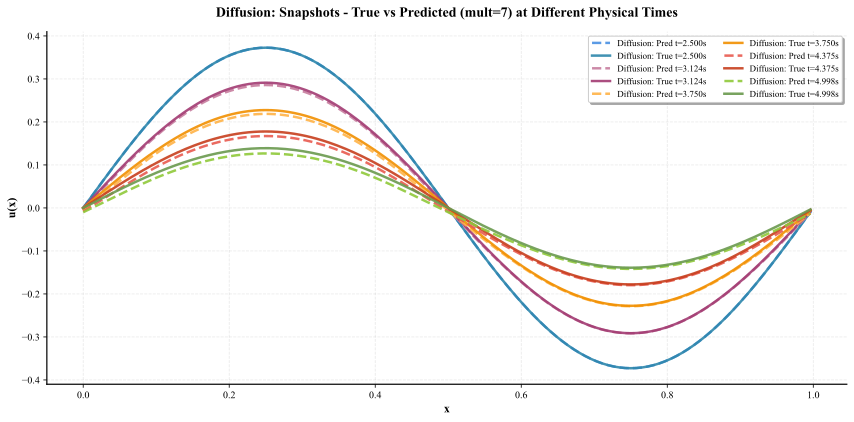

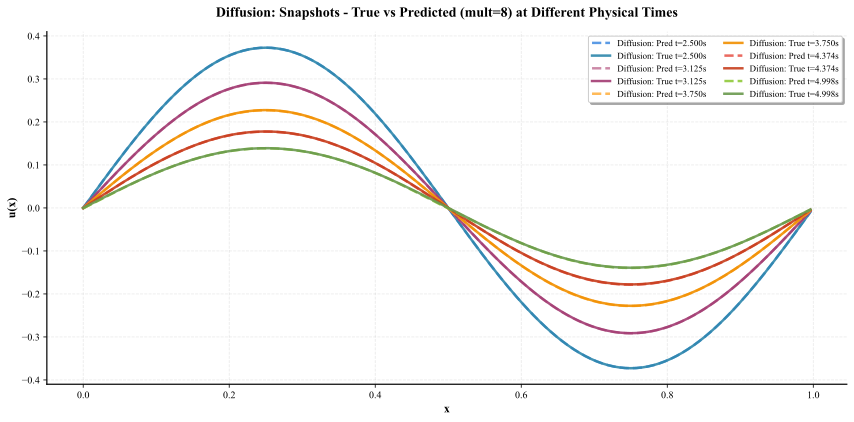

In [43]:
# %%
# =============================================================
# Plot: Snapshots at Multiple Times for Different Multipliers
# =============================================================

dt0 = 1e-4
train_end_step = T_train   # 25,000

# Loop over multipliers 1 through 8
for mult in range(1, 9):
    
    # ===== Run rollout for this multiplier =====
    model.eval()
    
    u_pred = u_test_true[0].clone()
    u_pred = u_pred.unsqueeze(0)
    
    rollout_pred_mult = [u_pred[0].detach().cpu().numpy()]
    rollout_true_mult = [u_test_true[0].detach().cpu().numpy()]
    
    # Adjust number of steps based on multiplier
    steps_mult = u_test_true.shape[0] // mult
    
    with torch.no_grad():
        for t in range(steps_mult - 1):
            
            u_now = rollout_pred_mult[-1]
            u_now = torch.from_numpy(u_now).to(device)
            
            u_left  = torch.roll(u_now, +1)
            u_right = torch.roll(u_now, -1)
            
            # dt = mult * dt0 for this multiplier
            dt_vec = torch.ones_like(u_now) * mult
            
            u_next = model(u_left, u_now, u_right, dt_vec)
            
            rollout_pred_mult.append(u_next.detach().cpu().numpy())
            rollout_true_mult.append(u_test_true[t * mult + mult].detach().cpu().numpy())
            
    rollout_pred_mult = np.stack(rollout_pred_mult)
    rollout_true_mult = np.stack(rollout_true_mult)
    
    # ===== Plot snapshots for this multiplier =====
    snapshot_ids = [0, steps_mult//4, steps_mult//2, 3*steps_mult//4, steps_mult-2]
    
    fig, ax = plt.subplots(figsize=(12, 6), dpi=300)
    
    colors_true = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E']
    colors_pred = ['#4A90E2', '#C77D9E', '#FFB347', '#E85A4F', '#8FC93A']
    
    for idx, sid in enumerate(snapshot_ids):
        t_global = (train_end_step + sid * mult) * dt0
        ax.plot(x, rollout_pred_mult[sid], label=f"Diffusion: Pred t={t_global:.3f}s", 
                linestyle="--", linewidth=2.5, color=colors_pred[idx], alpha=0.9)
        ax.plot(x, rollout_true_mult[sid], label=f"Diffusion: True t={t_global:.3f}s", 
                linewidth=2.5, color=colors_true[idx], alpha=0.9)
    
    ax.set_title(f"Diffusion: Snapshots - True vs Predicted (mult={mult}) at Different Physical Times", 
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel("x", fontsize=12, fontweight='bold')
    ax.set_ylabel("u(x)", fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
    ax.legend(ncol=2, frameon=True, fancybox=True, shadow=True, fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    # Save as PDF in diffusion figures folder (vector graphics preserve quality)
    fig.savefig(f'diffusion figures/diffusion_snapshots_mult{mult}.pdf', bbox_inches='tight', facecolor='white', edgecolor='none')
    plt.show()

## Rollout MSE Over Time
Plots MSE between true and predicted states across rollout steps.


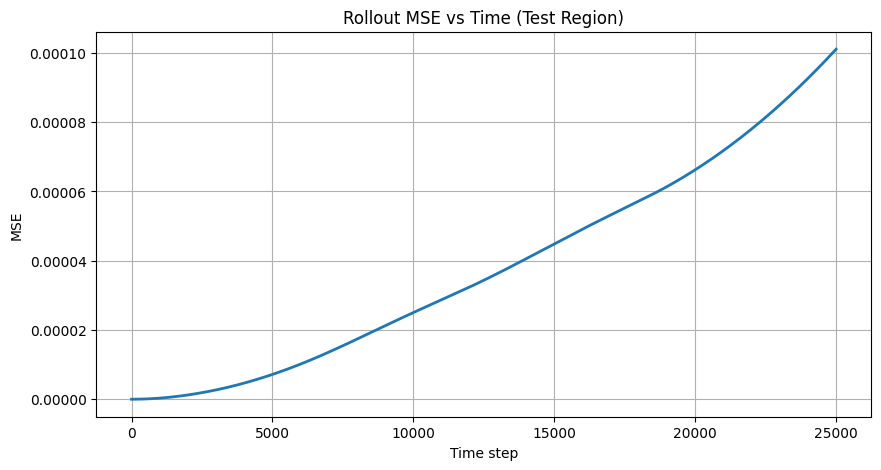

In [ ]:
# %%
mse_t = ((rollout_pred - rollout_true)**2).mean(axis=1)

fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

ax.plot(mse_t, linewidth=2.5, color='#2E86AB', label='Diffusion Rollout MSE', 
        marker='o', markersize=2, markevery=max(1, len(mse_t)//50))

ax.set_title("Diffusion: Rollout MSE vs Time (Test Region)", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Time step", fontsize=12, fontweight='bold')
ax.set_ylabel("MSE", fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
ax.legend(frameon=True, fancybox=True, shadow=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
# Save as PDF in diffusion figures folder (vector graphics preserve quality)
fig.savefig('diffusion figures/diffusion_rollout_mse.pdf', bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()


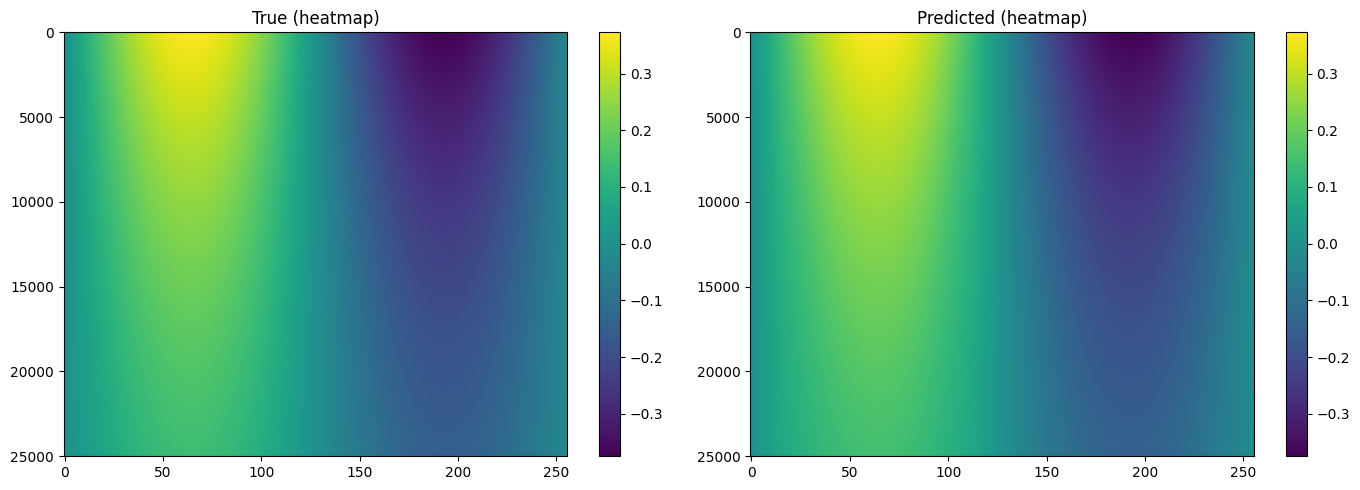

In [ ]:
# %%
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), dpi=300)
fig.suptitle("Diffusion: True vs Predicted Trajectories (Heatmap)", 
             fontsize=16, fontweight='bold', y=0.98)

im1 = ax1.imshow(rollout_true, aspect="auto", cmap="viridis", interpolation='bilinear')
ax1.set_title("Diffusion: True", fontsize=13, fontweight='bold', pad=10)
ax1.set_xlabel("Spatial Index", fontsize=12, fontweight='bold')
ax1.set_ylabel("Time Step", fontsize=12, fontweight='bold')
cbar1 = plt.colorbar(im1, ax=ax1)
cbar1.set_label("u(x,t)", fontsize=11, fontweight='bold')

im2 = ax2.imshow(rollout_pred, aspect="auto", cmap="viridis", interpolation='bilinear')
ax2.set_title("Diffusion: Predicted", fontsize=13, fontweight='bold', pad=10)
ax2.set_xlabel("Spatial Index", fontsize=12, fontweight='bold')
ax2.set_ylabel("Time Step", fontsize=12, fontweight='bold')
cbar2 = plt.colorbar(im2, ax=ax2)
cbar2.set_label("u(x,t)", fontsize=11, fontweight='bold')

plt.tight_layout()
# Save as PDF in diffusion figures folder (vector graphics preserve quality)
fig.savefig('diffusion figures/diffusion_heatmap.pdf', bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()


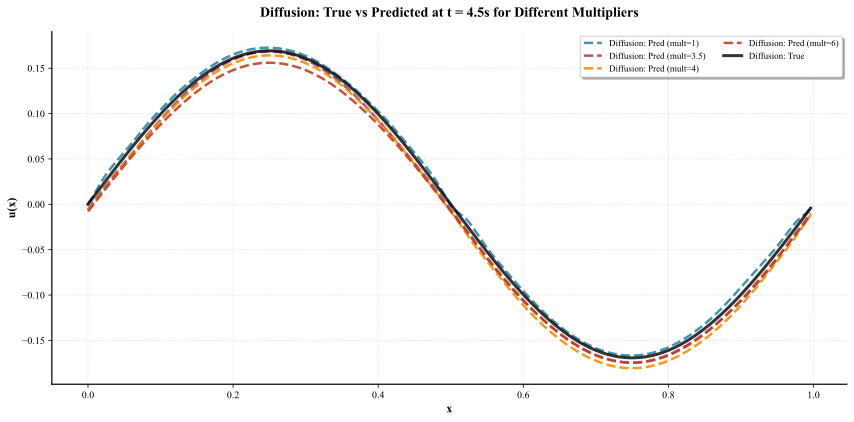

In [49]:
# %%
# =============================================================
# Plot: True vs Predicted at Fixed Time (4.5s) for Each Multiplier
# =============================================================

dt0 = 1e-4
train_end_step = T_train   # 25,000
target_time = 4.5  # Target time in seconds

# Calculate the global step corresponding to target_time
target_global_step = int(target_time / dt0)
target_test_step = target_global_step - train_end_step  # Step within test region

# Only proceed if target time is within test region
if target_test_step > 0 and target_test_step < u_test_true.shape[0]:
    multipliers = [1 , 3.5, 4,  6]
    
    fig, ax = plt.subplots(figsize=(12, 6), dpi=300)
    
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#8B5A3C', '#6C5CE7', '#00B894']
    
    for idx, mult in enumerate(multipliers):
        model.eval()
        
        # Run rollout for this multiplier
        u_pred = u_test_true[0].clone().unsqueeze(0)
        rollout_pred_mult = [u_pred[0].detach().cpu().numpy()]
        rollout_true_mult = [u_test_true[0].detach().cpu().numpy()]
        
        steps = int(u_test_true.shape[0] // mult)
        
        with torch.no_grad():
            for t in range(steps - 1):
                u_now = torch.from_numpy(rollout_pred_mult[-1]).to(device)
                
                u_left  = torch.roll(u_now, +1)
                u_right = torch.roll(u_now, -1)
                dt_vec = torch.ones_like(u_now) * mult
                
                u_next = model(u_left, u_now, u_right, dt_vec)
                
                rollout_pred_mult.append(u_next.detach().cpu().numpy())
                true_idx = int((t + 1) * mult)
                if true_idx < u_test_true.shape[0]:
                    rollout_true_mult.append(u_test_true[true_idx].detach().cpu().numpy())
                else:
                    break
        
        rollout_pred_mult = np.stack(rollout_pred_mult)
        rollout_true_mult = np.stack(rollout_true_mult)
        
        # Find the index in rollout that corresponds to target_time
        # For multiplier mult, each step advances by mult*dt0 in physical time
        target_rollout_step = int(target_test_step / mult)
        
        # Ensure index is within bounds
        if target_rollout_step < len(rollout_pred_mult) and target_rollout_step < len(rollout_true_mult):
            # Store predicted solution for this multiplier
            pred_at_time = rollout_pred_mult[target_rollout_step]
            
            ax.plot(x, pred_at_time, 
                   label=f"Diffusion: Pred (mult={mult})", 
                   linewidth=2.5, color=colors[idx % len(colors)], alpha=0.9, linestyle='--')
    
    # Plot true solution once (same for all multipliers at the same time)
    true_at_time = u_test_true[target_test_step].detach().cpu().numpy()
    ax.plot(x, true_at_time, label="Diffusion: True", 
           linewidth=3, color='black', alpha=0.8, linestyle='-', zorder=10)
    
    ax.set_title(f"Diffusion: True vs Predicted at t = {target_time}s for Different Multipliers", 
                fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel("x", fontsize=12, fontweight='bold')
    ax.set_ylabel("u(x)", fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
    ax.legend(ncol=2, frameon=True, fancybox=True, shadow=True, fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    # Save as PDF in diffusion figures folder (vector graphics preserve quality)
    fig.savefig(f'diffusion figures/diffusion_fixed_time_{target_time}s.pdf', bbox_inches='tight', facecolor='white', edgecolor='none')
    plt.show()
else:
    print(f"Target time {target_time}s is outside the test region. Test region spans from t={train_end_step*dt0:.3f}s to t={(train_end_step + u_test_true.shape[0])*dt0:.3f}s")
